# 単一Prefixの詳細分析

selected native Prefixを1つ指定し、Raw、Broad removed、Broad remainingの観測事実を比較します。PCAPの再解析やpipelineの実行は行わず、成功済みrun manifestに登録されたcanonical artifactだけを読みます。canonical `src_ip` / `dst_ip` とmembershipの `src_match` / `dst_match` は観測方向の事実であり、接続のinitiator/responderを表しません。TCPの接続先候補は、plain SYNを観測したflowの `initial_syn_receiver_ip` / `initial_syn_receiver_port` からのみ確認します。

## 解析設定

In [1]:
DATASET_ID = "202604081400"
RUN_NAME = "n3_m2"
TARGET_PREFIX = "163.29.158.43/32"

TOP_N_PORTS = 10
TOP_N_TARGETS = 10


## Artifact読み込みとprovenance

In [2]:
from pathlib import Path
import ipaddress
import json
import os

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

from mawi_global_analysis.comparison import build_comparison_flow_inclusion
from mawi_global_analysis.io import load_run

japanese_font_candidates = ('Hiragino Sans', 'Noto Sans CJK JP', 'Noto Serif CJK JP', 'IPAexGothic', 'YuGothic', 'Meiryo')
available_font_names = {font.name for font in font_manager.fontManager.ttflist}
japanese_font = next((font for font in japanese_font_candidates if font in available_font_names), None)
if japanese_font is None:
    raise RuntimeError('日本語グリフを含むMatplotlibフォントが見つかりません')
plt.rcParams['font.family'] = japanese_font
plt.rcParams['axes.unicode_minus'] = False

def resolve_analysis_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'src' / 'mawi_global_analysis').is_dir():
            return candidate
    return Path.cwd()

root = Path(os.environ.get('MAWI_ANALYSIS_ROOT', resolve_analysis_root())).resolve()
run = load_run(DATASET_ID, RUN_NAME, root=root)
saved_config = yaml.safe_load(run.manifest.get('config', {}).get('text', ''))
if not isinstance(saved_config, dict):
    raise ValueError('run manifest内の保存済みconfigを読み取れません')
# scan.broad.enabled must be true for this Raw/Broad deep dive.
if saved_config.get('scan', {}).get('broad', {}).get('enabled') is not True:
    raise ValueError('指定runはscan.broad.enabled == Trueではありません。Broad有効の成功済みrunを指定してください')

artifact_paths = run.manifest.get('artifacts', {})
provenance = pd.DataFrame([{
    'データセット': DATASET_ID,
    '実行名': RUN_NAME,
    '対象native Prefix': TARGET_PREFIX,
    'manifest status': run.manifest.get('status'),
    'config hash': run.manifest.get('config', {}).get('hash'),
    'input SHA-256': run.manifest.get('input', {}).get('sha256'),
    'Git commit': run.manifest.get('git_commit'),
    'flows artifact': artifact_paths.get('flows', {}).get('path'),
    'flow_labels artifact': artifact_paths.get('flow_labels', {}).get('path'),
    'membership artifact': artifact_paths.get('flow_prefix_membership', {}).get('path'),
}])
display(provenance)


,データセット,実行名,対象native Prefix,manifest status,config hash,input SHA-256,Git commit,flows artifact,flow_labels artifact,membership artifact
0,202604081400,n3_m2,163.29.158.43/32,success,2268881f56ad09c5588e4b8e65db953f33f0f451ae2e6c...,5869ff3cd1b8cbe247def8c50fc5eb0d5d0c8df84222d3...,3a6810c2811805c9bb47aa59dea2785a7f312860,/home/s-sakai/mawi-global-analysis/data/202604...,/home/s-sakai/mawi-global-analysis/results/202...,/home/s-sakai/mawi-global-analysis/results/202...


## Prefix validation

In [3]:
selected_native_prefixes = (
    run.prefixes.loc[run.prefixes['selected_for_analysis'] == True, 'prefix']
    .drop_duplicates()
    .sort_values()
    .tolist()
)
if TARGET_PREFIX not in selected_native_prefixes:
    available = '\n'.join(f'  - {prefix}' for prefix in selected_native_prefixes)
    raise ValueError(
        f'指定したTARGET_PREFIXはselected native Prefixに存在しません: {TARGET_PREFIX}\n'
        f'利用可能なselected native Prefix:\n{available}'
    )
display(pd.DataFrame({'selected native Prefix': selected_native_prefixes}))


,selected native Prefix
0,131.142.206.160/32
1,131.142.238.168/32
2,133.132.116.53/32
3,142.11.234.5/32
4,150.217.137.141/32
5,150.217.140.38/32
6,151.34.117.44/32
7,157.53.116.0/28
8,157.53.116.16/28
9,157.53.44.81/32


## 対象flow DataFrameの構築

In [4]:
required_flow_columns = {
    'flow_id', 'ip_version', 'protocol', 'packet_count', 'byte_count', 'frame_byte_count',
    'ip_byte_count', 'transport_payload_byte_count', 'duration', 'observed_tcp_pattern',
    'initial_syn_sender_ip', 'initial_syn_sender_port',
    'initial_syn_receiver_ip', 'initial_syn_receiver_port',
}
missing_flow_columns = sorted(required_flow_columns - set(run.flows.columns))
if missing_flow_columns:
    raise ValueError(f'flowsに必要な列がありません: {missing_flow_columns}')
if run.flows['flow_id'].duplicated().any():
    raise ValueError('flows.flow_idが一意ではありません')
if run.labels['flow_id'].duplicated().any():
    raise ValueError('labels.flow_idが一意ではありません')
if set(run.flows['flow_id']) != set(run.labels['flow_id']):
    raise ValueError('flowsとlabelsのflow_id集合が一致しません')

# membership全体を結合せず、単一native Prefixを先に絞ることで行増殖を防ぐ。
target_membership = run.membership.loc[
    run.membership['analysis_scope'].eq('native')
    & run.membership['analysis_prefix'].eq(TARGET_PREFIX)
].copy()
if target_membership.empty:
    raise ValueError(f'TARGET_PREFIXのnative membershipがありません: {TARGET_PREFIX}')
if target_membership['flow_id'].duplicated().any():
    raise ValueError('target membershipのflow_idが一意ではありません')
if not set(target_membership['flow_id']).issubset(set(run.flows['flow_id'])):
    raise ValueError('target membershipにflows外のflow_idが含まれます')

inclusion = build_comparison_flow_inclusion(run.flows, run.labels)
flow_facts = run.flows.merge(
    run.labels.loc[:, ['flow_id', 'broad_removed']], on='flow_id', how='inner', validate='one_to_one'
).merge(
    inclusion, on='flow_id', how='inner', validate='one_to_one'
)
target_flows = target_membership.merge(
    flow_facts, on='flow_id', how='inner', validate='one_to_one'
).copy()
if len(target_flows) != len(target_membership):
    raise ValueError('target flow joinで意図しない行数変化が発生しました')
target_flows['broad_removed'] = target_flows['broad_removed'].astype(bool)
if not target_flows['raw_included'].all() or not (target_flows['broad_included'] == ~target_flows['broad_removed']).all():
    raise ValueError('Raw/Broad inclusionとbroad_removedの対応が不正です')
target_flows['group'] = np.where(target_flows['broad_removed'], 'Broad removed', 'Broad remaining')
raw_target_flows = target_flows
broad_removed_flows = target_flows.loc[target_flows['broad_removed']].copy()
broad_remaining_flows = target_flows.loc[target_flows['broad_included']].copy()
if len(broad_removed_flows) + len(broad_remaining_flows) != len(raw_target_flows):
    raise AssertionError('Broad removed + Broad remaining == Raw')
if not (pd.to_numeric(target_flows['byte_count'], errors='raise') == pd.to_numeric(target_flows['frame_byte_count'], errors='raise')).all():
    raise ValueError('byte_countとframe_byte_countが同値ではありません')

groups = {
    'Raw': raw_target_flows,
    'Broad removed': broad_removed_flows,
    'Broad remaining': broad_remaining_flows,
}
display(pd.DataFrame([{
    'TARGET_PREFIX': TARGET_PREFIX,
    'native membership行数': len(target_membership),
    'Raw flow数': len(raw_target_flows),
    'Broad removed + Broad remaining == Raw': True,
}]))


,TARGET_PREFIX,native membership行数,Raw flow数,Broad removed + Broad remaining == Raw
0,163.29.158.43/32,289,289,True


## Basic Raw / Broad statistics

In [5]:
def ratio_percent(values):
    return float(values.mean() * 100) if len(values) else np.nan

def numeric_median(frame, column):
    return pd.to_numeric(frame[column], errors='coerce').median() if len(frame) else np.nan

raw_median_packet_count = numeric_median(raw_target_flows, 'packet_count')
remaining_median_packet_count = numeric_median(broad_remaining_flows, 'packet_count')
basic_statistics = pd.DataFrame([{
    'Prefix': TARGET_PREFIX,
    'Raw flow count': len(raw_target_flows),
    'Broad removed flow count': len(broad_removed_flows),
    'Broad remaining flow count': len(broad_remaining_flows),
    'Broad removed ratio [%]': ratio_percent(raw_target_flows['broad_removed']),
    'Raw median packet_count': raw_median_packet_count,
    'Broad remaining median packet_count': remaining_median_packet_count,
    'packet_count median change rate [%]': ((remaining_median_packet_count - raw_median_packet_count) / raw_median_packet_count * 100) if pd.notna(raw_median_packet_count) and raw_median_packet_count != 0 else np.nan,
    'Removed median packet_count': numeric_median(broad_removed_flows, 'packet_count'),
    'Remaining median packet_count': remaining_median_packet_count,
    'Raw one-packet ratio [%]': ratio_percent(raw_target_flows['packet_count'].eq(1)),
    'Removed one-packet ratio [%]': ratio_percent(broad_removed_flows['packet_count'].eq(1)),
    'Remaining one-packet ratio [%]': ratio_percent(broad_remaining_flows['packet_count'].eq(1)),
    'Raw tiny-flow (<=3) ratio [%]': ratio_percent(raw_target_flows['packet_count'].le(3)),
    'Removed tiny-flow (<=3) ratio [%]': ratio_percent(broad_removed_flows['packet_count'].le(3)),
    'Remaining tiny-flow (<=3) ratio [%]': ratio_percent(broad_remaining_flows['packet_count'].le(3)),
}])
display(basic_statistics)


,Prefix,Raw flow count,Broad removed flow count,Broad remaining flow count,Broad removed ratio [%],Raw median packet_count,Broad remaining median packet_count,packet_count median change rate [%],Removed median packet_count,Remaining median packet_count,Raw one-packet ratio [%],Removed one-packet ratio [%],Remaining one-packet ratio [%],Raw tiny-flow (<=3) ratio [%],Removed tiny-flow (<=3) ratio [%],Remaining tiny-flow (<=3) ratio [%]
0,163.29.158.43/32,289,57,232,19.723183,17.0,23.0,35.294118,1.0,23.0,28.719723,100.0,11.206897,32.179931,100.0,15.517241


## packet_count分析

,group,count,Q25,median,Q75,Q90,Q99,max,packet_count == 1 ratio [%],packet_count <= 3 ratio [%]
0,Raw,289,1.0,17.0,50.0,193.4,404980.80,577321,28.719723,32.179931
1,Broad removed,57,1.0,1.0,1.0,1.0,1.00,1,100.000000,100.000000
2,Broad remaining,232,10.0,23.0,60.0,320.2,428558.85,577321,11.206897,15.517241


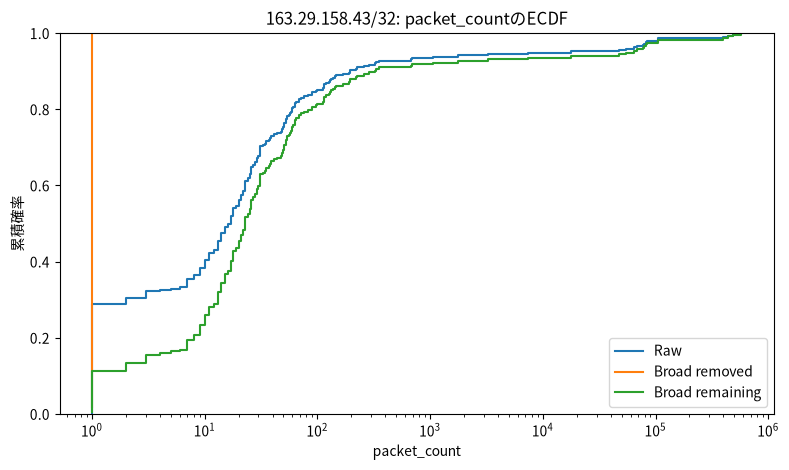

In [6]:
def packet_distribution_summary(name, frame):
    packets = pd.to_numeric(frame['packet_count'], errors='coerce').dropna()
    return {
        'group': name, 'count': len(packets), 'Q25': packets.quantile(.25) if len(packets) else np.nan,
        'median': packets.median() if len(packets) else np.nan, 'Q75': packets.quantile(.75) if len(packets) else np.nan,
        'Q90': packets.quantile(.90) if len(packets) else np.nan, 'Q99': packets.quantile(.99) if len(packets) else np.nan,
        'max': packets.max() if len(packets) else np.nan,
        'packet_count == 1 ratio [%]': ratio_percent(packets.eq(1)),
        'packet_count <= 3 ratio [%]': ratio_percent(packets.le(3)),
    }

packet_distribution = pd.DataFrame([packet_distribution_summary(name, frame) for name, frame in groups.items()])
display(packet_distribution)

def ecdf(values):
    ordered = np.sort(np.asarray(values, dtype=float))
    return ordered, np.arange(1, len(ordered) + 1) / len(ordered)

figure, axis = plt.subplots(figsize=(8, 4.8))
for name, frame in groups.items():
    packets = pd.to_numeric(frame['packet_count'], errors='coerce').dropna()
    if len(packets):
        x, y = ecdf(packets)
        axis.step(x, y, where='post', label=name)
axis.set(title=f'{TARGET_PREFIX}: packet_countのECDF', xlabel='packet_count', ylabel='累積確率', xscale='log', ylim=(0, 1))
axis.legend()
figure.tight_layout()


## TCP pattern分析

In [7]:
PATTERN_ORDER = ['syn_only_observed', 'syn_to_rst', 'syn_synack_rst', 'その他', 'none']

def is_tcp(frame):
    return frame['protocol'].astype(str).isin({'6', '6.0', 'tcp'})

def pattern_bucket(value):
    return value if value in {'syn_only_observed', 'syn_to_rst', 'syn_synack_rst', 'none'} else 'その他'

pattern_rows = []
for name, frame in groups.items():
    tcp = frame.loc[is_tcp(frame)].copy()
    bucketed = tcp['observed_tcp_pattern'].fillna('none').map(pattern_bucket)
    for pattern in PATTERN_ORDER:
        count = int(bucketed.eq(pattern).sum())
        pattern_rows.append({'group': name, 'TCP flow count': len(tcp), 'observed_tcp_pattern': pattern, 'flow count': count, 'ratio within TCP flows [%]': count / len(tcp) * 100 if len(tcp) else np.nan})
tcp_pattern_comparison = pd.DataFrame(pattern_rows)
display(tcp_pattern_comparison)


,group,TCP flow count,observed_tcp_pattern,flow count,ratio within TCP flows [%]
0,Raw,193,syn_only_observed,163,84.455959
1,Raw,193,syn_to_rst,0,0.000000
2,Raw,193,syn_synack_rst,5,2.590674
3,Raw,193,その他,0,0.000000
4,Raw,193,none,25,12.953368
5,Broad removed,57,syn_only_observed,57,100.000000
6,Broad removed,57,syn_to_rst,0,0.000000
7,Broad removed,57,syn_synack_rst,0,0.000000
8,Broad removed,57,その他,0,0.000000
9,Broad removed,57,none,0,0.000000


## 接続先 / 推定サービス候補

In [8]:
def tcp_with_initial_syn(frame):
    return frame.loc[
        is_tcp(frame)
        & frame['initial_syn_receiver_ip'].notna()
        & frame['initial_syn_receiver_port'].notna()
    ].copy()

def service_candidate(port):
    port = int(port)
    known = {22: 'SSH関連サービス候補', 80: 'HTTP関連サービス候補', 443: 'HTTPS/TLS関連サービス候補', 53: 'DNS関連サービス候補', 25: 'SMTP関連サービス候補'}
    if port in known:
        return f'TCP/{port}: {known[port]}'
    if port >= 49152:
        return f'TCP/{port}: dynamic/high port（port番号だけでは用途不明）'
    return f'TCP/{port}: port番号だけでは用途不明'

def receiver_port_summary(name, frame):
    syn_tcp = tcp_with_initial_syn(frame)
    if syn_tcp.empty:
        return pd.DataFrame(columns=['group', 'receiver port', 'flow count', 'group ratio [%]', 'median packet_count', 'median duration', 'unique receiver IP count', 'Service candidate'])
    result = syn_tcp.groupby('initial_syn_receiver_port', as_index=False).agg(
        **{'flow count': ('flow_id', 'size'), 'median packet_count': ('packet_count', 'median'), 'median duration': ('duration', 'median'), 'unique receiver IP count': ('initial_syn_receiver_ip', 'nunique')}
    ).sort_values(['flow count', 'initial_syn_receiver_port'], ascending=[False, True]).head(TOP_N_PORTS).rename(columns={'initial_syn_receiver_port': 'receiver port'})
    result.insert(0, 'group', name)
    result['group ratio [%]'] = result['flow count'] / len(syn_tcp) * 100
    result['Service candidate'] = result['receiver port'].map(service_candidate)
    return result

receiver_port_comparison = pd.concat([
    receiver_port_summary('Broad removed', broad_removed_flows),
    receiver_port_summary('Broad remaining', broad_remaining_flows),
], ignore_index=True)
display(receiver_port_comparison)


,group,receiver port,flow count,median packet_count,median duration,unique receiver IP count,group ratio [%],Service candidate
0,Broad removed,22.0,1,1.0,0.000000,1,1.754386,TCP/22: SSH関連サービス候補
1,Broad removed,43.0,1,1.0,0.000000,1,1.754386,TCP/43: port番号だけでは用途不明
2,Broad removed,208.0,1,1.0,0.000000,1,1.754386,TCP/208: port番号だけでは用途不明
3,Broad removed,314.0,1,1.0,0.000000,1,1.754386,TCP/314: port番号だけでは用途不明
4,Broad removed,443.0,1,1.0,0.000000,1,1.754386,TCP/443: HTTPS/TLS関連サービス候補
5,Broad removed,789.0,1,1.0,0.000000,1,1.754386,TCP/789: port番号だけでは用途不明
6,Broad removed,1002.0,1,1.0,0.000000,1,1.754386,TCP/1002: port番号だけでは用途不明
7,Broad removed,1447.0,1,1.0,0.000000,1,1.754386,TCP/1447: port番号だけでは用途不明
8,Broad removed,2086.0,1,1.0,0.000000,1,1.754386,TCP/2086: port番号だけでは用途不明
9,Broad removed,2121.0,1,1.0,0.000000,1,1.754386,TCP/2121: port番号だけでは用途不明


## Receiver IP / target diversity

In [9]:
diversity_rows = []
for name, frame in groups.items():
    syn_tcp = tcp_with_initial_syn(frame)
    diversity_rows.append({
        'group': name, 'TCP flows with observed plain SYN': len(syn_tcp),
        'unique initial_syn_receiver_ip': syn_tcp['initial_syn_receiver_ip'].nunique(),
        'unique initial_syn_receiver_port': syn_tcp['initial_syn_receiver_port'].nunique(),
        'unique (receiver IP, receiver port)': syn_tcp.loc[:, ['initial_syn_receiver_ip', 'initial_syn_receiver_port']].drop_duplicates().shape[0],
    })
target_diversity = pd.DataFrame(diversity_rows)
display(target_diversity)

removed_syn_tcp = tcp_with_initial_syn(broad_removed_flows)
top_removed_receiver_ips = removed_syn_tcp.groupby('initial_syn_receiver_ip', as_index=False).agg(
    **{'flow count': ('flow_id', 'size'), 'unique receiver ports': ('initial_syn_receiver_port', 'nunique'), 'median packet_count': ('packet_count', 'median')}
).sort_values(['flow count', 'initial_syn_receiver_ip'], ascending=[False, True]).head(TOP_N_TARGETS)
top_removed_receiver_pairs = removed_syn_tcp.groupby(['initial_syn_receiver_ip', 'initial_syn_receiver_port'], as_index=False).agg(
    **{'flow count': ('flow_id', 'size'), 'median packet_count': ('packet_count', 'median'), 'median duration': ('duration', 'median')}
).sort_values(['flow count', 'initial_syn_receiver_ip', 'initial_syn_receiver_port'], ascending=[False, True, True]).head(TOP_N_TARGETS)
display(top_removed_receiver_ips)
display(top_removed_receiver_pairs)


,group,TCP flows with observed plain SYN,unique initial_syn_receiver_ip,unique initial_syn_receiver_port,"unique (receiver IP, receiver port)"
0,Raw,178,25,66,88
1,Broad removed,57,1,57,57
2,Broad remaining,121,25,12,33


,initial_syn_receiver_ip,flow count,unique receiver ports,median packet_count
0,163.29.158.43,57,57,1.0


,initial_syn_receiver_ip,initial_syn_receiver_port,flow count,median packet_count,median duration
0,163.29.158.43,22.0,1,1.0,0.0
1,163.29.158.43,43.0,1,1.0,0.0
2,163.29.158.43,208.0,1,1.0,0.0
3,163.29.158.43,314.0,1,1.0,0.0
4,163.29.158.43,443.0,1,1.0,0.0
5,163.29.158.43,789.0,1,1.0,0.0
6,163.29.158.43,1002.0,1,1.0,0.0
7,163.29.158.43,1447.0,1,1.0,0.0
8,163.29.158.43,2086.0,1,1.0,0.0
9,163.29.158.43,2121.0,1,1.0,0.0


## Broad removedの送信元・port多様性

以下は、TCPかつinitial SYN sender/receiver IP・receiver portを観測できたBroad removed flowだけを対象にした観測集計です。canonical `src_ip` / `dst_ip` は送信元・接続先の代用にしません。

In [10]:
def broad_removed_with_complete_initial_syn_endpoints(frame):
    return frame.loc[
        is_tcp(frame)
        & frame['initial_syn_sender_ip'].notna()
        & frame['initial_syn_receiver_ip'].notna()
        & frame['initial_syn_receiver_port'].notna()
    ].copy()

def dominant_observed_tcp_pattern(values):
    counts = values.fillna('none').value_counts()
    if counts.empty:
        return '該当なし'
    tied_patterns = sorted(counts.index[counts.eq(counts.max())].tolist())
    return tied_patterns[0] if len(tied_patterns) == 1 else 'なし（同率）'

removed_sender_endpoint_flows = broad_removed_with_complete_initial_syn_endpoints(broad_removed_flows)
removed_sender_endpoint_flows = removed_sender_endpoint_flows.assign(
    _receiver_endpoint=list(zip(
        removed_sender_endpoint_flows['initial_syn_receiver_ip'],
        removed_sender_endpoint_flows['initial_syn_receiver_port'],
    ))
)
sender_diversity_by_sender = (
    removed_sender_endpoint_flows.groupby('initial_syn_sender_ip', as_index=False).agg(
        flow_count=('flow_id', 'size'),
        unique_receiver_ips=('initial_syn_receiver_ip', 'nunique'),
        unique_receiver_ports=('initial_syn_receiver_port', 'nunique'),
        unique_receiver_endpoints=('_receiver_endpoint', 'nunique'),
        median_packet_count=('packet_count', 'median'),
        dominant_observed_tcp_pattern=('observed_tcp_pattern', dominant_observed_tcp_pattern),
    )
    .sort_values(['unique_receiver_ports', 'flow_count', 'initial_syn_sender_ip'], ascending=[False, False, True])
    .reset_index(drop=True)
)

sender_diversity_summary = pd.DataFrame([{
    'removed flow count': len(removed_sender_endpoint_flows),
    'unique initial_syn_sender_ip': sender_diversity_by_sender['initial_syn_sender_ip'].nunique(),
    'unique initial_syn_receiver_ip': removed_sender_endpoint_flows['initial_syn_receiver_ip'].nunique(),
    'unique initial_syn_receiver_port': removed_sender_endpoint_flows['initial_syn_receiver_port'].nunique(),
    'unique (sender IP, receiver IP, receiver port)': removed_sender_endpoint_flows.loc[:, ['initial_syn_sender_ip', 'initial_syn_receiver_ip', 'initial_syn_receiver_port']].drop_duplicates().shape[0],
    'flows per sender median': sender_diversity_by_sender['flow_count'].median() if len(sender_diversity_by_sender) else 0,
    'flows per sender max': sender_diversity_by_sender['flow_count'].max() if len(sender_diversity_by_sender) else 0,
    'unique receiver ports per sender median': sender_diversity_by_sender['unique_receiver_ports'].median() if len(sender_diversity_by_sender) else 0,
    'unique receiver ports per sender max': sender_diversity_by_sender['unique_receiver_ports'].max() if len(sender_diversity_by_sender) else 0,
    'unique receiver IPs per sender median': sender_diversity_by_sender['unique_receiver_ips'].median() if len(sender_diversity_by_sender) else 0,
    'unique receiver IPs per sender max': sender_diversity_by_sender['unique_receiver_ips'].max() if len(sender_diversity_by_sender) else 0,
}])
display(sender_diversity_summary)
display(sender_diversity_by_sender.head(TOP_N_TARGETS))


,removed flow count,unique initial_syn_sender_ip,unique initial_syn_receiver_ip,unique initial_syn_receiver_port,"unique (sender IP, receiver IP, receiver port)",flows per sender median,flows per sender max,unique receiver ports per sender median,unique receiver ports per sender max,unique receiver IPs per sender median,unique receiver IPs per sender max
0,57,25,1,57,57,1.0,33,1.0,33,1.0,1


,initial_syn_sender_ip,flow_count,unique_receiver_ips,unique_receiver_ports,unique_receiver_endpoints,median_packet_count,dominant_observed_tcp_pattern
0,93.139.29.123,33,1,33,33,1.0,syn_only_observed
1,141.34.6.196,1,1,1,1,1.0,syn_only_observed
2,147.73.115.102,1,1,1,1,1.0,syn_only_observed
3,154.51.197.182,1,1,1,1,1.0,syn_only_observed
4,170.166.216.207,1,1,1,1,1.0,syn_only_observed
5,176.254.109.210,1,1,1,1,1.0,syn_only_observed
6,176.254.109.254,1,1,1,1,1.0,syn_only_observed
7,176.254.109.31,1,1,1,1,1.0,syn_only_observed
8,192.82.52.220,1,1,1,1,1.0,syn_only_observed
9,195.77.191.193,1,1,1,1,1.0,syn_only_observed


## byte / duration / payload分析

In [11]:
def byte_duration_payload_summary(name, frame):
    return {
        'group': name, 'flow count': len(frame),
        'total frame_byte_count': pd.to_numeric(frame['frame_byte_count'], errors='coerce').sum(),
        'median frame_byte_count': numeric_median(frame, 'frame_byte_count'),
        'total ip_byte_count': pd.to_numeric(frame['ip_byte_count'], errors='coerce').sum(),
        'median ip_byte_count': numeric_median(frame, 'ip_byte_count'),
        'total transport_payload_byte_count': pd.to_numeric(frame['transport_payload_byte_count'], errors='coerce').sum(),
        'median transport_payload_byte_count': numeric_median(frame, 'transport_payload_byte_count'),
        'transport_payload_byte_count == 0 ratio [%]': ratio_percent(frame['transport_payload_byte_count'].eq(0)),
        'median duration': numeric_median(frame, 'duration'),
        'Q90 duration': pd.to_numeric(frame['duration'], errors='coerce').quantile(.90) if len(frame) else np.nan,
    }

byte_duration_payload = pd.DataFrame([byte_duration_payload_summary(name, frame) for name, frame in groups.items()])
display(byte_duration_payload)
display(pd.DataFrame([{'byte_count == frame_byte_count': True, '注記': 'byte_countはlegacy互換のEthernet frame byte totalのため、重複統計は表示しない'}]))


,group,flow count,total frame_byte_count,median frame_byte_count,total ip_byte_count,median ip_byte_count,total transport_payload_byte_count,median transport_payload_byte_count,transport_payload_byte_count == 0 ratio [%],median duration,Q90 duration
0,Raw,289,178784914,888.0,140804496,644.0,0,0.0,100.0,3.132016,370.764742
1,Broad removed,57,3338,58.0,2540,44.0,0,0.0,100.0,0.000000,0.000000
2,Broad remaining,232,178781576,1347.0,140801956,1018.0,0,0.0,100.0,55.731958,370.942854


,byte_count == frame_byte_count,注記
0,True,byte_countはlegacy互換のEthernet frame byte totalの...


## Prefix側のinitial SYN role

In [12]:
target_network = ipaddress.ip_network(TARGET_PREFIX)

def endpoint_in_target(value):
    return pd.notna(value) and ipaddress.ip_address(str(value)) in target_network

def syn_role(frame):
    sender_in_target = frame['initial_syn_sender_ip'].map(endpoint_in_target)
    receiver_in_target = frame['initial_syn_receiver_ip'].map(endpoint_in_target)
    return np.select(
        [sender_in_target & ~receiver_in_target, receiver_in_target & ~sender_in_target, sender_in_target & receiver_in_target],
        ['initial SYN sender', 'initial SYN receiver', 'both'],
        default='unknown',
    )

role_rows = []
role_order = ['initial SYN sender', 'initial SYN receiver', 'both', 'unknown']
for name, frame in groups.items():
    syn_tcp = tcp_with_initial_syn(frame)
    roles = pd.Series(syn_role(syn_tcp), index=syn_tcp.index) if len(syn_tcp) else pd.Series(dtype='object')
    for role in role_order:
        count = int(roles.eq(role).sum())
        role_rows.append({'group': name, '母集団: initial SYN観測TCP flow数': len(syn_tcp), 'Prefix-side SYN role': role, 'flow count': count, 'ratio within observed-SYN TCP [%]': count / len(syn_tcp) * 100 if len(syn_tcp) else np.nan})
syn_role_comparison = pd.DataFrame(role_rows)
display(syn_role_comparison)


,group,母集団: initial SYN観測TCP flow数,Prefix-side SYN role,flow count,ratio within observed-SYN TCP [%]
0,Raw,178,initial SYN sender,112,62.921348
1,Raw,178,initial SYN receiver,66,37.078652
2,Raw,178,both,0,0.000000
3,Raw,178,unknown,0,0.000000
4,Broad removed,57,initial SYN sender,0,0.000000
5,Broad removed,57,initial SYN receiver,57,100.000000
6,Broad removed,57,both,0,0.000000
7,Broad removed,57,unknown,0,0.000000
8,Broad remaining,121,initial SYN sender,112,92.561983
9,Broad remaining,121,initial SYN receiver,9,7.438017


## Removed-flow audit

In [13]:
removed_flow_audit_columns = [
    'flow_id', 'protocol', 'observed_tcp_pattern',
    'initial_syn_sender_ip', 'initial_syn_sender_port',
    'initial_syn_receiver_ip', 'initial_syn_receiver_port',
    'packet_count', 'frame_byte_count', 'transport_payload_byte_count', 'duration',
]
removed_flow_audit = broad_removed_flows.loc[:, removed_flow_audit_columns].sort_values('flow_id', kind='stable').reset_index(drop=True)
display(pd.DataFrame([{'Broad removed flow数': len(removed_flow_audit), 'Notebook上の表示行数': min(20, len(removed_flow_audit))}]))
display(removed_flow_audit.head(20))


,Broad removed flow数,Notebook上の表示行数
0,57,20


,flow_id,protocol,observed_tcp_pattern,initial_syn_sender_ip,initial_syn_sender_port,initial_syn_receiver_ip,initial_syn_receiver_port,packet_count,frame_byte_count,transport_payload_byte_count,duration
0,1092216,6,syn_only_observed,92.62.73.25,57598.0,163.29.158.43,22.0,1,54,0,0.0
1,1327071,6,syn_only_observed,93.139.29.123,44737.0,163.29.158.43,5256.0,1,58,0,0.0
2,1725796,6,syn_only_observed,93.139.29.123,44721.0,163.29.158.43,4949.0,1,58,0,0.0
3,1750147,6,syn_only_observed,93.139.29.123,44737.0,163.29.158.43,15018.0,1,58,0,0.0
4,1772431,6,syn_only_observed,93.139.29.123,44737.0,163.29.158.43,9455.0,1,58,0,0.0
5,2622857,6,syn_only_observed,93.139.29.123,44721.0,163.29.158.43,22000.0,1,58,0,0.0
6,4715573,6,syn_only_observed,93.139.29.123,44721.0,163.29.158.43,8069.0,1,58,0,0.0
7,5938798,6,syn_only_observed,93.139.29.123,44721.0,163.29.158.43,8581.0,1,58,0,0.0
8,6007417,6,syn_only_observed,93.139.29.123,44737.0,163.29.158.43,9113.0,1,58,0,0.0
9,6622728,6,syn_only_observed,93.139.29.123,44721.0,163.29.158.43,2086.0,1,58,0,0.0


## Summary

以下は観測値の要約です。除外理由や通信/applicationの意味を自動的に断定するものではありません。

In [14]:
removed_tcp_patterns = tcp_pattern_comparison.loc[tcp_pattern_comparison['group'].eq('Broad removed')].sort_values(['flow count', 'observed_tcp_pattern'], ascending=[False, True])
removed_receiver_port_counts = removed_syn_tcp.groupby('initial_syn_receiver_port', as_index=False).agg(
    **{'flow count': ('flow_id', 'size')}
).sort_values(['flow count', 'initial_syn_receiver_port'], ascending=[False, True]).reset_index(drop=True)
if removed_receiver_port_counts.empty:
    max_removed_flows_per_receiver_port = 0
    receiver_ports_tied_for_max = 0
    dominant_removed_receiver_port = '該当なし'
else:
    max_removed_flows_per_receiver_port = int(removed_receiver_port_counts['flow count'].max())
    receiver_ports_tied_for_max = int(removed_receiver_port_counts['flow count'].eq(max_removed_flows_per_receiver_port).sum())
    dominant_removed_receiver_port = (
        int(removed_receiver_port_counts.loc[removed_receiver_port_counts['flow count'].eq(max_removed_flows_per_receiver_port), 'initial_syn_receiver_port'].iloc[0])
        if receiver_ports_tied_for_max == 1 else 'なし（同率）'
    )
removed_roles = syn_role_comparison.loc[syn_role_comparison['group'].eq('Broad removed')].set_index('Prefix-side SYN role')['ratio within observed-SYN TCP [%]']
summary = pd.DataFrame([{
    'prefix': TARGET_PREFIX,
    'Raw flow count': len(raw_target_flows),
    'Broad removed count': len(broad_removed_flows),
    'Broad remaining count': len(broad_remaining_flows),
    'Broad removed ratio [%]': ratio_percent(raw_target_flows['broad_removed']),
    'Raw median packet_count': raw_median_packet_count,
    'Broad median packet_count': remaining_median_packet_count,
    'median change rate [%]': ((remaining_median_packet_count - raw_median_packet_count) / raw_median_packet_count * 100) if pd.notna(raw_median_packet_count) and raw_median_packet_count != 0 else np.nan,
    'removed median packet_count': numeric_median(broad_removed_flows, 'packet_count'),
    'remaining median packet_count': remaining_median_packet_count,
    'removed one-packet ratio [%]': ratio_percent(broad_removed_flows['packet_count'].eq(1)),
    'dominant removed TCP pattern': removed_tcp_patterns.iloc[0]['observed_tcp_pattern'] if len(removed_tcp_patterns) else np.nan,
    'unique removed SYN senders': sender_diversity_by_sender['initial_syn_sender_ip'].nunique(),
    'median removed flows per sender': sender_diversity_by_sender['flow_count'].median() if len(sender_diversity_by_sender) else 0,
    'max removed flows per sender': sender_diversity_by_sender['flow_count'].max() if len(sender_diversity_by_sender) else 0,
    'median unique receiver ports per sender': sender_diversity_by_sender['unique_receiver_ports'].median() if len(sender_diversity_by_sender) else 0,
    'max unique receiver ports per sender': sender_diversity_by_sender['unique_receiver_ports'].max() if len(sender_diversity_by_sender) else 0,
    'unique removed receiver ports': removed_receiver_port_counts['initial_syn_receiver_port'].nunique(),
    'max removed flows per receiver port': max_removed_flows_per_receiver_port,
    'number of receiver ports tied for max': receiver_ports_tied_for_max,
    'dominant removed receiver port': dominant_removed_receiver_port,
    'unique removed receiver IP count': removed_syn_tcp['initial_syn_receiver_ip'].nunique(),
    'Prefix-side SYN sender ratio [%]': removed_roles.get('initial SYN sender', np.nan),
    'Prefix-side SYN receiver ratio [%]': removed_roles.get('initial SYN receiver', np.nan),
}])
display(summary)


,prefix,Raw flow count,Broad removed count,Broad remaining count,Broad removed ratio [%],Raw median packet_count,Broad median packet_count,median change rate [%],removed median packet_count,remaining median packet_count,...,max removed flows per sender,median unique receiver ports per sender,max unique receiver ports per sender,unique removed receiver ports,max removed flows per receiver port,number of receiver ports tied for max,dominant removed receiver port,unique removed receiver IP count,Prefix-side SYN sender ratio [%],Prefix-side SYN receiver ratio [%]
0,163.29.158.43/32,289,57,232,19.723183,17.0,23.0,35.294118,1.0,23.0,...,33,1.0,33,57,1,57,なし（同率）,1,0.0,100.0
